In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv('2003-2025 Championships.csv')
print(df.columns.tolist())
print(df.shape)

['Name', 'Age', 'Country', 'Points', 'Dive', 'Dive No.', 'DD', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'Dive Pts', 'Total Pts', 'Year', 'Round']
(3010, 18)


In [4]:
df_filtered = df[(df['Year'] >= 2022) & (df['Year'] <= 2025) & (df['Round'] == 'Final')].copy()
print("(2022-2025 Final)data shape:", df_filtered.shape)

(2022-2025 Final)data shape: (240, 18)


In [5]:
numeric_cols = ['Year', 'DD', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7']
for col in numeric_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

In [6]:
df_filtered = df_filtered.dropna(subset=numeric_cols)
print("after outliner handling data shape", df_filtered.shape)

after outliner handling data shape (240, 18)


In [7]:
def calculate_valid_score(row):
    """
    Calculate the valid referee scores: Remove the 2 highest and 2 lowest scores from the 7 referee scores, and take the sum of the remaining 3
    """
    judge_scores = [row[f'J{i}'] for i in range(1, 8)]
    judge_scores_sorted = sorted(judge_scores)
    valid_scores = judge_scores_sorted[2:-2]  
    return sum(valid_scores)
df_filtered['Valid_Judge_Sum'] = df_filtered.apply(calculate_valid_score, axis=1)

In [8]:
#The highest theoretical score
df_filtered['Theoretical_Max'] = df_filtered['DD'] * 10 * 3

#The actual score of a single jump
df_filtered['Actual_Score'] = (df_filtered['Valid_Judge_Sum'] * df_filtered['DD']).round(2)

#Deduction value
df_filtered['Deduction'] = df_filtered['Theoretical_Max'] - df_filtered['Actual_Score']
df_filtered['Deduction'] = df_filtered['Deduction'].apply(lambda x: max(x, 0))

#Deduction rate (deduction value/theoretical maximum score ×100%)
df_filtered['Deduction_Rate'] = (df_filtered['Deduction'] / df_filtered['Theoretical_Max'] * 100).round(2)

print(df_filtered[['Year', 'DD', 'Valid_Judge_Sum', 'Actual_Score','Theoretical_Max', 'Deduction', 'Deduction_Rate']].head())

      Year   DD  Valid_Judge_Sum  Actual_Score  Theoretical_Max  Deduction  \
2065  2022  3.0             27.0         81.00             90.0       9.00   
2066  2022  3.2             28.5         91.20             96.0       4.80   
2067  2022  3.3             26.0         85.80             99.0      13.20   
2068  2022  3.3             24.5         80.85             99.0      18.15   
2069  2022  3.2             24.5         78.40             96.0      17.60   

      Deduction_Rate  
2065           10.00  
2066            5.00  
2067           13.33  
2068           18.33  
2069           18.33  


In [9]:
overall_stats = df_filtered[['DD', 'Actual_Score', 'Deduction', 'Deduction_Rate']].describe()
print(overall_stats)

               DD  Actual_Score   Deduction  Deduction_Rate
count  240.000000    240.000000  240.000000      240.000000
mean     3.103333     65.778750   27.321250       29.368167
std      0.178995     13.216944   12.620087       13.318718
min      2.000000     26.600000    0.000000        0.000000
25%      3.000000     58.375000   19.200000       20.000000
50%      3.200000     65.600000   27.200000       30.000000
75%      3.200000     72.000000   35.200000       36.670000
max      3.600000     99.000000   66.300000       68.330000


In [27]:
df_filtered['Difficulty_Group'] = pd.cut(
    df_filtered['DD'],
    bins=[2.5, 2.9,3.0,3.3,3.6],
    labels=['2.5-2.9','3.0-3.1','3.2-3.3','3.4-3.6'],   #中低难度、中高难度、高难度
    right=False
)
group_stats = df_filtered.groupby('Difficulty_Group')[['Actual_Score', 'Deduction', 'Deduction_Rate']].agg(['mean', 'std']).round(2)
print(group_stats)

                 Actual_Score        Deduction        Deduction_Rate       
                         mean    std      mean    std           mean    std
Difficulty_Group                                                           
2.5-2.9                 58.07  11.20     25.93  11.20          30.86  13.34
3.0-3.1                 56.72   8.41     30.28   8.41          34.80   9.66
3.2-3.3                 67.32  11.56     26.90  11.40          28.55  12.07
3.4-3.6                 70.58  20.49     28.64  20.67          28.83  20.74


In [56]:
# Screen countries with a sample size of ≥15
country_count = df_filtered['Country'].value_counts()
valid_countries = country_count[country_count >=15].index.tolist()
df_country = df_filtered[df_filtered['Country'].isin(valid_countries)].copy()
print(f"\n======= Effective analysis countries (sample size ≥15) =======\n{valid_countries}")


======= Effective analysis countries (sample size ≥15) =======
['CHN', 'GER', 'MEX', 'AUS', 'USA', 'CAN', 'JPN', 'ITA', 'GBR']


In [57]:
country_stats = df_country.groupby('Country').agg({
    'DD': 'mean',          
    'Deduction_Rate': 'mean',     
    'Year': 'count'                
}).round(4)
country_stats.columns = ['Avg_Difficulty', 'Avg_Deduction_Rate', 'Sample_Count']

print(country_stats)

         Avg_Difficulty  Avg_Deduction_Rate  Sample_Count
Country                                                  
AUS              3.0850             36.5835            20
CAN              3.1000             29.0835            20
CHN              3.1825             11.2912            40
GBR              3.0800             26.5560            15
GER              3.1000             35.5332            25
ITA              3.1000             32.8893            15
JPN              2.9733             32.4447            15
MEX              3.1840             35.5340            25
USA              3.1450             35.8335            20


In [58]:
mean_diff = country_stats['Avg_Difficulty'].mean()
std_diff = country_stats['Avg_Difficulty'].std()
mean_ded = country_stats['Avg_Deduction_Rate'].mean()
std_ded = country_stats['Avg_Deduction_Rate'].std()
print(f"mean_diff:{mean_diff}")
print(f"std_diff:{std_diff}")
print(f"mean_ded:{mean_ded}")
print(f"std_ded:{std_ded}")

mean_diff:3.1055333333333333
std_diff:0.06353107507354179
mean_ded:30.638766666666672
std_ded:7.9998934783533215


In [59]:
high_diff_thresh = mean_diff + std_diff    
low_diff_thresh = mean_diff - std_diff 
print(f"high_diff_thresh:{high_diff_thresh}")
print(f"low_diff_thresh:{low_diff_thresh}")

high_diff_thresh:3.169064408406875
low_diff_thresh:3.0420022582597914


In [60]:
def classify_country(row):
    avg_diff = row['Avg_Difficulty']
    avg_ded = row['Avg_Deduction_Rate']
    if avg_diff >= 3.18 and avg_ded <= 15:
        return 'High Difficulty High Quality', 'Outstanding in strength type'
    elif avg_diff >= 3.18 and avg_ded >= 35:
        return 'High Difficulty Low Quality', 'High-difficulty challenge type'
    else:
        return 'Middel Difficulty Middel Quality', 'Ordinary type'

country_stats[['Classification', 'Strategy_Type']] = country_stats.apply(classify_country, axis=1, result_type='expand')
print(country_stats[['Avg_Difficulty', 'Avg_Deduction_Rate', 'Sample_Count', 'Classification', 'Strategy_Type']])

         Avg_Difficulty  Avg_Deduction_Rate  Sample_Count  \
Country                                                     
AUS              3.0850             36.5835            20   
CAN              3.1000             29.0835            20   
CHN              3.1825             11.2912            40   
GBR              3.0800             26.5560            15   
GER              3.1000             35.5332            25   
ITA              3.1000             32.8893            15   
JPN              2.9733             32.4447            15   
MEX              3.1840             35.5340            25   
USA              3.1450             35.8335            20   

                           Classification                   Strategy_Type  
Country                                                                    
AUS      Middel Difficulty Middel Quality                   Ordinary type  
CAN      Middel Difficulty Middel Quality                   Ordinary type  
CHN          High Diffic

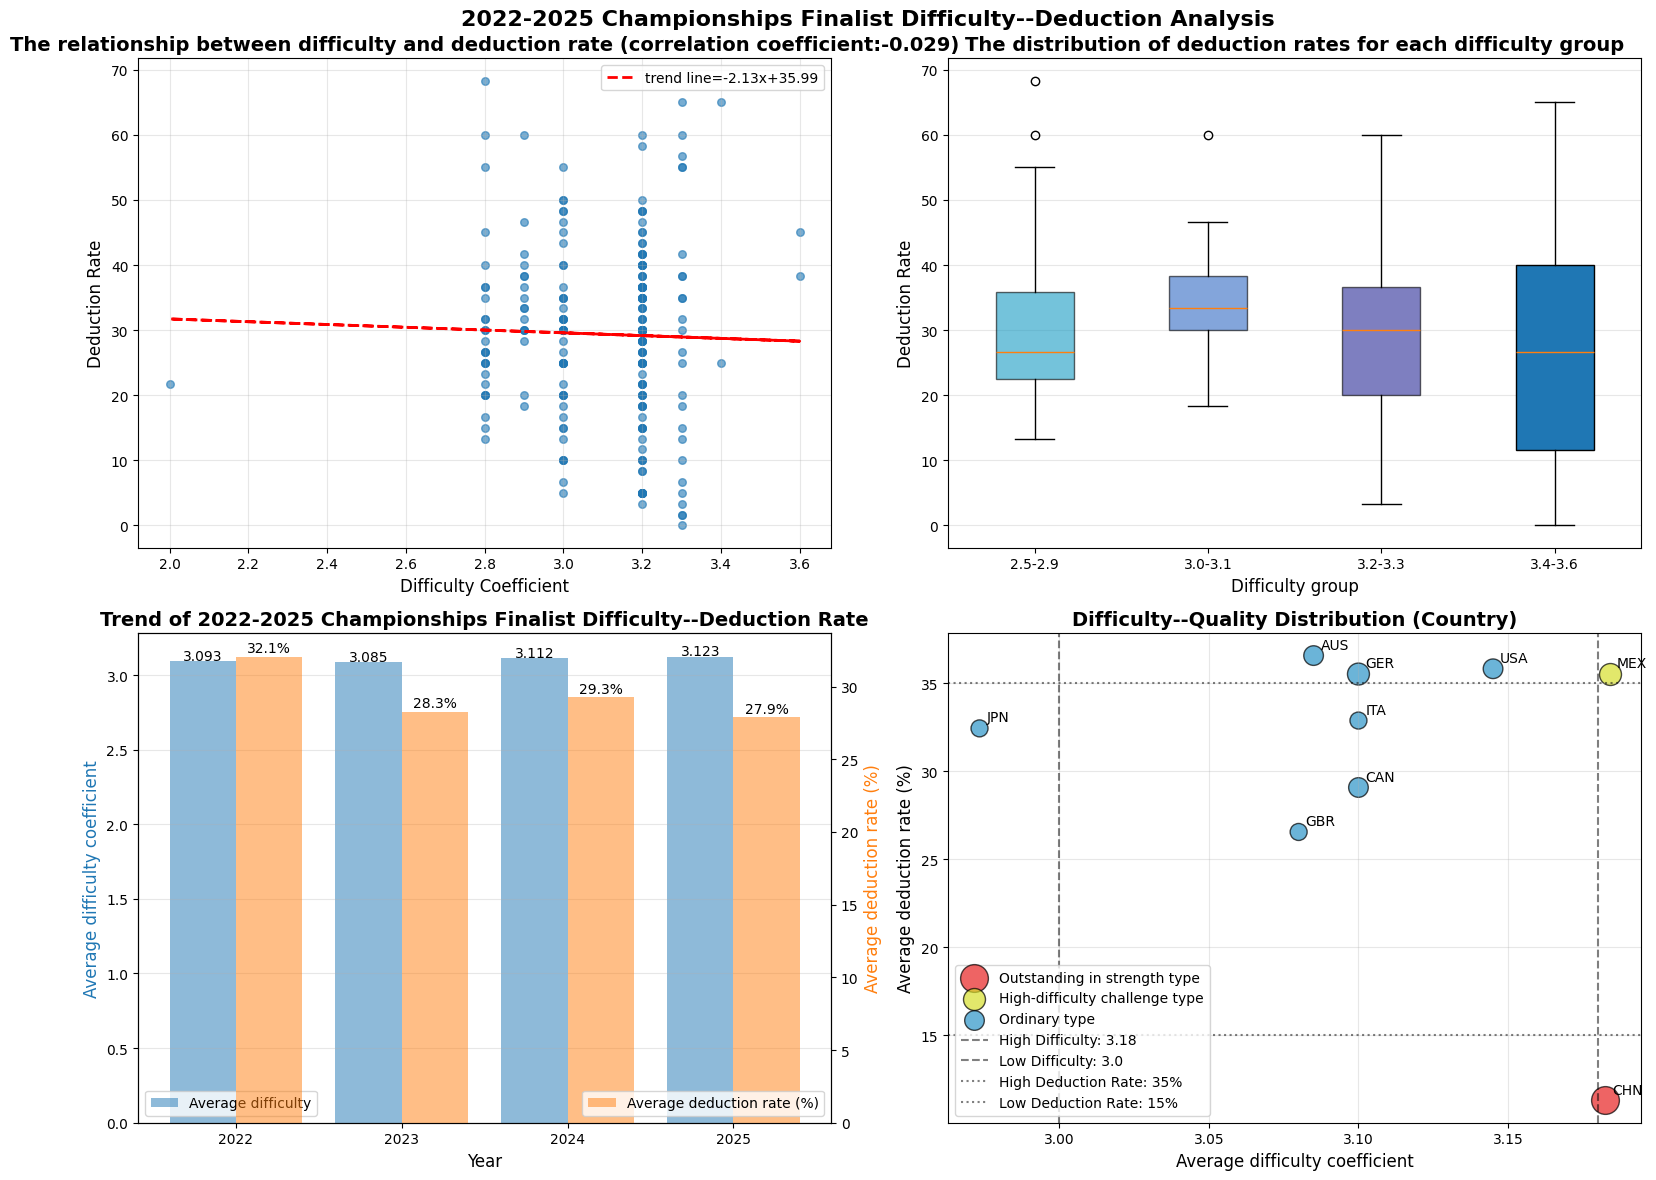


picture has been saved to: dive difficulty and deduction analysis (country).png


In [68]:
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('2022-2025 Championships Finalist Difficulty--Deduction Analysis', fontsize=16, fontweight='bold')

# 子图1：难度系数 vs 扣分率（散点图+趋势线）
ax1 = axs[0, 0]
x = df_filtered['DD']
y = df_filtered['Deduction_Rate']
ax1.scatter(x, y, alpha=0.6, s=30, color='#1f77b4')
# 趋势线
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax1.plot(x, p(x), 'r--', linewidth=2, label=f'trend line={z[0]:.2f}x+{z[1]:.2f}')
# 相关系数
corr = np.corrcoef(x, y)[0, 1]
ax1.set_xlabel('Difficulty Coefficient', fontsize=12)
ax1.set_ylabel('Deduction Rate', fontsize=12)
ax1.set_title(f'The relationship between difficulty and deduction rate (correlation coefficient:{corr:.3f})', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 子图2：各难度组扣分率分布（箱线图）
ax2 = axs[0, 1]
groups = ['2.5-2.9','3.0-3.1','3.2-3.3','3.4-3.6']
box_data = [df_filtered[df_filtered['Difficulty_Group'] == g]['Deduction_Rate'] for g in groups]
bp = ax2.boxplot(box_data, labels=groups, patch_artist=True)
# 配色
colors = ["#189bc3", "#3069C4", "#292A96"]
for patch, color in zip(bp['boxes'], colors,):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_xlabel('Difficulty group', fontsize=12)
ax2.set_ylabel('Deduction Rate', fontsize=12)
ax2.set_title('The distribution of deduction rates for each difficulty group', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# 子图3：各年度指标对比
ax3 = axs[1, 0]
years = sorted(df_filtered['Year'].unique())
avg_diff_year = df_filtered.groupby('Year')['DD'].mean()
avg_ded_year = df_filtered.groupby('Year')['Deduction_Rate'].mean()
# 双Y轴
ax3_twin = ax3.twinx()
bar1 = ax3.bar([y-0.2 for y in years], avg_diff_year, 0.4, label='Average difficulty', color='#1f77b4',alpha=0.5)
bar2 = ax3_twin.bar([y+0.2 for y in years], avg_ded_year, 0.4, label='Average deduction rate (%)', color='#ff7f0e',alpha=0.5)
# 数值标签
for bar in bar1:
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.3f}', ha='center')
for bar in bar2:
    ax3_twin.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{bar.get_height():.1f}%', ha='center')
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Average difficulty coefficient', fontsize=12, color='#1f77b4')
ax3_twin.set_ylabel('Average deduction rate (%)', fontsize=12, color='#ff7f0e')
ax3.set_title('Trend of 2022-2025 Championships Finalist Difficulty--Deduction Rate', fontsize=14, fontweight='bold')
ax3.set_xticks(years)
ax3.legend(loc='lower left')
ax3_twin.legend(loc='lower right')
ax3.grid(alpha=0.3, axis='y')

# 子图4：各国难度-扣分率分布（散点图）
ax4 = axs[1, 1]
# 按策略类型配色
strat_colors = {
    'Outstanding in strength type': "#e82323",
    'High-difficulty challenge type': "#d6df2c",
    'Ordinary type': "#2c94c8"
}
# 绘制散点
for strat, color in strat_colors.items():
    data = country_stats[country_stats['Strategy_Type'] == strat]
    ax4.scatter(
        data['Avg_Difficulty'],
        data['Avg_Deduction_Rate'],
        s=data['Sample_Count']*10,  
        color=color,
        label=strat,
        alpha=0.7,
        edgecolors='black'
    )
# 国家标签
for idx, row in country_stats.iterrows():
    ax4.annotate(idx, (row['Avg_Difficulty'], row['Avg_Deduction_Rate']), xytext=(5,5), textcoords='offset points', fontsize=10)
# 阈值线
ax4.axvline(3.18, color='black', linestyle='--', alpha=0.5, label=f'High Difficulty: 3.18')
ax4.axvline(3.0, color='black', linestyle='--', alpha=0.5, label=f'Low Difficulty: 3.0')
ax4.axhline(35, color='black', linestyle=':', alpha=0.5, label=f'High Deduction Rate: 35%')
ax4.axhline(15, color='black', linestyle=':', alpha=0.5, label=f'Low Deduction Rate: 15%')
ax4.set_xlabel('Average difficulty coefficient', fontsize=12)
ax4.set_ylabel('Average deduction rate (%)', fontsize=12)
ax4.set_title('Difficulty--Quality Distribution (Country)', fontsize=14, fontweight='bold')
ax4.legend(loc='lower left')
ax4.grid(alpha=0.3)

# 保存图表
plt.tight_layout()
plt.savefig('dive_analysis_corrected.png', dpi=300, bbox_inches='tight')
plt.show()
print("\npicture has been saved to: dive difficulty and deduction analysis (country).png")


In [69]:
country_diff_stats = df_filtered.groupby(['Country', 'Difficulty_Group']).agg(
    Avg_Deduction_Rate=('Deduction_Rate', 'mean'),  # 平均扣分率
    Sample_Count=('Deduction_Rate', 'count')         # 该国家在该难度组的动作数（样本量）
).round(2).reset_index()

In [70]:
country_diff_stats = country_diff_stats[country_diff_stats['Sample_Count'] >= 5].copy()

In [71]:
top_countries = df_filtered['Country'].value_counts().head(6).index.tolist()
country_diff_stats = country_diff_stats[country_diff_stats['Country'].isin(top_countries)].copy()

In [72]:
print(country_diff_stats.head(10))

   Country Difficulty_Group  Avg_Deduction_Rate  Sample_Count
2      AUS          3.2-3.3               37.71            16
10     CAN          3.2-3.3               25.42            12
14     CHN          3.2-3.3               11.67            29
15     CHN          3.4-3.6               10.30            11
25     GER          3.0-3.1               36.67             5
26     GER          3.2-3.3               35.25            20
42     MEX          3.2-3.3               31.36            16
43     MEX          3.4-3.6               43.33             5
58     USA          3.2-3.3               36.43            14


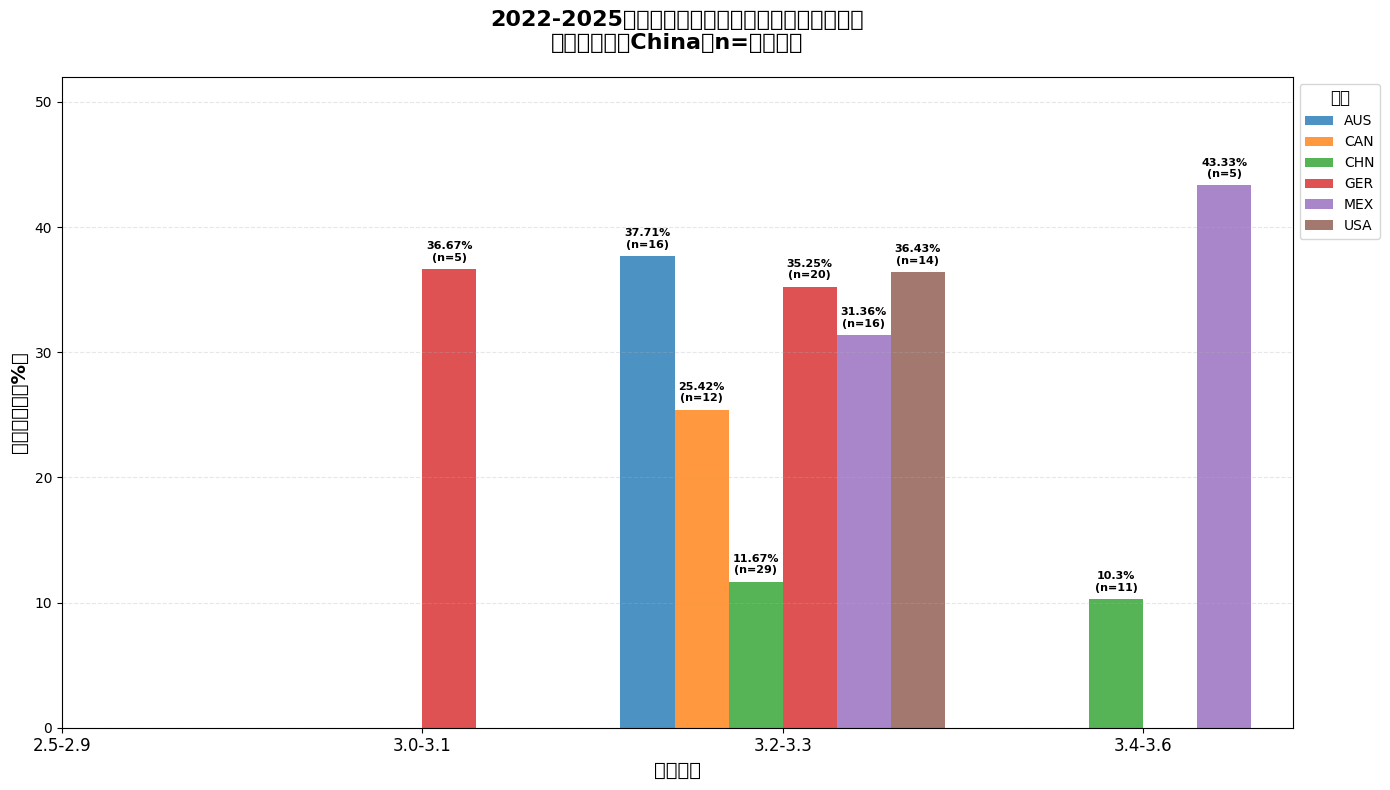

✅ 图表已保存：country_difficulty_deduction_China.png
💡 从图表中可直观查看China在哪个难度组的扣分率最低（柱子越矮越好）


In [73]:
# -------------------------- 2. 绘制分组柱状图：突出目标国家的优势难度组 --------------------------
# 2.1 设置关键参数（可按需修改）
target_country = "China"  # 目标国家（需与数据中的国家名称完全一致，如"USA"）
difficulty_groups = ['2.5-2.9','3.0-3.1','3.2-3.3','3.4-3.6']  # 难度组顺序（固定）
bar_width = 0.15  # 柱子宽度（根据国家数量调整，国家越多宽度越小）
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']  # 颜色列表（国家数量需匹配）
target_color = '#ff4444'  # 目标国家的特殊颜色（红色，突出显示）

# 2.2 计算x轴位置（每个难度组下，不同国家的柱子偏移）
x = np.arange(len(difficulty_groups))  # 难度组的基础x坐标（0,1,2）
countries = country_diff_stats['Country'].unique()  # 所有要展示的国家
offsets = np.arange(len(countries)) * bar_width  # 每个国家的偏移量（0, 0.15, 0.3...）

# 2.3 创建画布
plt.figure(figsize=(14, 8))

# 2.4 循环绘制每个国家的柱子
for i, country in enumerate(countries):
    # 筛选当前国家的所有难度组数据
    country_data = country_diff_stats[country_diff_stats['Country'] == country]
    
    # 确保每个难度组都有数据（无数据则填充NaN，柱子不显示）
    deduction_rates = []
    sample_counts = []
    for diff_group in difficulty_groups:
        group_data = country_data[country_data['Difficulty_Group'] == diff_group]
        if not group_data.empty:
            deduction_rates.append(group_data['Avg_Deduction_Rate'].iloc[0])
            sample_counts.append(group_data['Sample_Count'].iloc[0])
        else:
            deduction_rates.append(np.nan)  # 无数据时用NaN，不绘制柱子
            sample_counts.append(0)
    
    # 确定当前国家的柱子颜色（目标国家用特殊颜色）
    current_color = target_color if country == target_country else colors[i % len(colors)]
    
    # 绘制柱子（x坐标=基础x + 偏移量）
    bars = plt.bar(
        x + offsets[i],  # 柱子的x坐标（偏移后）
        deduction_rates,  # 柱子高度（平均扣分率）
        width=bar_width,
        label=country,
        color=current_color,
        alpha=0.8,
        edgecolor='black' if country == target_country else 'none'  # 目标国家柱子加黑边框
    )
    
    # 为柱子添加“扣分率+样本量”标签（仅显示有数据的柱子）
    for j, (bar, rate, sample) in enumerate(zip(bars, deduction_rates, sample_counts)):
        if not np.isnan(rate):  # 仅对有数据的柱子添加标签
            plt.text(
                bar.get_x() + bar.get_width()/2,  # 标签x坐标（柱子中心）
                bar.get_height() + 0.5,  # 标签y坐标（柱子顶部+0.5，避免遮挡）
                f'{rate}%\n(n={sample})',  # 标签内容（扣分率+样本量）
                ha='center', va='bottom', fontsize=8, fontweight='bold'
            )

# 2.5 优化图表细节（标签、图例、标题等）
# x轴标签（难度组）
plt.xticks(x + offsets.mean(), difficulty_groups, fontsize=12)
plt.xlabel('难度组别', fontsize=14, fontweight='bold')

# y轴标签（平均扣分率，扣分率越低越好）
plt.ylabel('平均扣分率（%）', fontsize=14, fontweight='bold')
plt.ylim(0, max(country_diff_stats['Avg_Deduction_Rate']) * 1.2)  # y轴从0开始，顶部留20%空间

# 标题（突出目标国家）
plt.title(f'2022-2025跳水决赛各国在不同难度组的平均扣分率\n（突出显示：{target_country}，n=动作数）', 
          fontsize=16, fontweight='bold', pad=20)

# 图例（避免遮挡数据，放在右侧）
plt.legend(title='国家', title_fontsize=12, fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))

# 网格线（仅y轴，增加可读性）
plt.grid(axis='y', alpha=0.3, linestyle='--')

# 调整布局（避免标签被截断）
plt.tight_layout()

# 保存图表（高分辨率）
plt.savefig(f'country_difficulty_deduction_{target_country}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ 图表已保存：country_difficulty_deduction_{target_country}.png")
print(f"💡 从图表中可直观查看{target_country}在哪个难度组的扣分率最低（柱子越矮越好）")